In [1]:
import itertools
import re

import lightgbm as lgb
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import randint, uniform
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
def extract_quantity_keyword(text):
    text = text.lower()
    # if re.search(
    #    r"\b(tsd\.?|thousand|1,?000|10.3|kilo|kt|million kg|tausend|ktons|kiloton(ne)?s?)\b", text
    # ):
    if re.search(
        r"\b(tsd\.?|thousand|1,?000|10.?3t?|kilo|kt|tt|million kg|tausend|ktons|kiloton(ne)?s?)\b|\bkt(?=[A-Za-z])",
        text,
    ):
        return "kt"  # kilo/Tausend
    if re.search(
        r"\b(million(en)?|mio\.?|1,?000,?000|mega|megaton(ne)?s?n?|mm|mn|mmt(on)?(ne)?s?)\b", text
    ):
        return "Mt"  # Million
    if re.search(r"\b(kg|kilograms?)\b|\bkg(?=[A-Za-z])", text):
        return "kg"  # kilogram
    if re.search(r"\b(us[\s-]?ton(ne)?s?|ust|short tons?)\b", text):
        return "USt"  # US-tons
    return ""


def clean_unit(text):
    text = re.sub(r"[0-9\.,]+", "", text)
    text = re.sub(r"[^\w]+", " ", text)
    text = re.sub(r"\bof\b", "", text)
    return text.strip().lower()


def create_features_and_labels(
    unit_dict_new,
    extract_quantity_keyword,
    clean_unit,
    unit_col="unit",
    target_col="normalized_unit",
):
    """
    Erzeugt Feature-DataFrame X und encoded Label-Serie y_series.

    :param unit_dict_new: DataFrame mit Spalten für Einheiten und Ziel
    :param extract_quantity_keyword: Funktion, die auf Textmenge Menge-Key zurückliefert
    :param clean_unit: Funktion, die den Einheit-Text cleaned
    :param unit_col: Name der Spalte für die rohen Einheiten
    :param target_col: Name der Spalte für das Ziel
    :return: X (DataFrame), y_series (Series), LabelEncoder-Instanz
    """
    X_raw = unit_dict_new[unit_col]
    y = unit_dict_new[target_col]
    X_cleaned = X_raw.str.lower()
    X_cleaned = X_cleaned.str.replace(r"\d+[,\.]?\d*", "NUMBER", regex=True)
    quantity_feature = X_raw.apply(extract_quantity_keyword)
    unit_feature = X_raw.apply(clean_unit)
    length_feature = X_raw.str.len()
    X_df = pd.DataFrame(
        {
            "cleaned_text": X_cleaned,
            "quantity": quantity_feature,
            "unit_base": unit_feature,
            "length": length_feature,
        }
    )
    # Textfeature
    X_df["text"] = X_df["cleaned_text"] + " " + X_df["quantity"] + " " + X_df["unit_base"]
    X_df["orig_index"] = X_df.index
    X = X_df[["text", "length", "orig_index"]]

    # Label-Encoding für Y
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return X, y_encoded, le


def stratified_split_by_count(
    unit_dict_new, X, y_encoded, max_count=2, include_artificial=False, random_state=42
):
    """
    Aufteilung in Trainings-/Testdaten nach count, Label-stratifiziert.

    :param unit_dict_new: DataFrame mit mindestens Spalten "normalized_unit" und "count"
    :param X: Merkmals-DataFrame (gleicher Index wie unit_dict_new)
    :param y_series: Labels (gleicher Index wie unit_dict_new)
    :param max_count: Maximaler "count"-Wert, der als Testdatenkandidat gilt (z.B. 2 = count 1 und 2)
    :param include_artificial: Wenn True, werden auch alle mit count==1.5 zu den Kandidaten gezählt
    :param random_state: Seed für Zufallsauswahl
    :return: X_train, y_train, X_test, y_test
    """

    y_series = pd.Series(y_encoded, index=X["orig_index"])
    rng = np.random.RandomState(random_state)
    train_indices = []
    test_indices = []

    for unit, group in unit_dict_new.groupby("normalized_unit"):
        group_indices = group.index.values
        # Listen mit Testdaten-Kandidaten, sortiert nach count (klein nach groß)
        if include_artificial:
            candidate_mask = group["count"].isin(list(range(1, max_count + 1)) + [1.5])
        else:
            candidate_mask = group["count"].isin(list(range(1, max_count + 1)))
        candidates = group[candidate_mask].sort_values("count")
        candidate_indices = candidates.index.values

        n_total = len(group_indices)
        n_test_max = int(np.floor(0.2 * n_total))

        # Priorisiere immer die niedrigsten count! Wenn es zu viele sind -> zufällig aus niedrigsten wählen!
        if len(candidate_indices) > n_test_max:
            # Finde alle Indices mit minimalem count, dann fortlaufend... und fülle mit Zufalls-Auswahl auf
            # 1. Erzeuge Liste mit allen möglichen count-Werten, aufsteigend
            counts_sorted = sorted(candidates["count"].unique())
            selected_indices = []
            for c in counts_sorted:
                these = candidates[candidates["count"] == c].index.tolist()
                if len(selected_indices) + len(these) < n_test_max:
                    selected_indices.extend(these)
                else:
                    # Ziehe Zufalls-Auswahl genau bis zur 20%-Grenze auf
                    remaining = n_test_max - len(selected_indices)
                    selected_indices.extend(rng.choice(these, size=remaining, replace=False))
                    break
            test_sample = selected_indices
            train_sample = np.setdiff1d(group_indices, test_sample)
        else:
            test_sample = candidate_indices
            train_sample = np.setdiff1d(group_indices, test_sample)

        test_indices.extend(test_sample)
        train_indices.extend(train_sample)

    # Shuffle
    train_indices = rng.permutation(train_indices)
    test_indices = rng.permutation(test_indices)

    X_train = X.loc[train_indices].reset_index(drop=True)
    y_train = y_series.loc[train_indices].values
    X_test = X.loc[test_indices].reset_index(drop=True)
    y_test = y_series.loc[test_indices].values
    return X_train, y_train, X_test, y_test


def build_and_train_pipeline(
    X_train,
    y_train,
    ml_model,
    voting_models=None,
    mode="build_and_train",
):
    """
    Baut eine Vorverarbeitungs- und Klassifikationspipeline, trainiert auf den gegebenen Daten.
    :param X_train: DataFrame mit mind. den Spalten 'text' und 'length'
    :param y_train: Zielklasse als array-ähnliches Objekt
    :param ml_model: Modell-Name (z.B. 'xgb', 'lightgbm', 'logistic_regression', 'voting_classifier', ...)
    :param mode: "build_and_train" oder anderes, falls kein training ausgeführt wird
    :param voting_models: optionale Liste von Modellnamen für VotingClassifier, z.B.
                          ["xgb", "lightgbm", "logistic_regression"]
    :return: trainierte Pipeline
    """
    # Preprocessing: Text + numerisch
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                # TfidfVectorizer( # optimal for xgboost
                #    analyzer="char_wb",
                #    max_features=2000,
                #    ngram_range=(1, 4),
                #    min_df=2,
                #    max_df=0.95,
                #    sublinear_tf=False,
                # ),
                TfidfVectorizer(  # optimal for logistic_regression
                    analyzer="char_wb",
                    max_features=1000,
                    ngram_range=(1, 3),
                    min_df=3,
                    max_df=0.95,
                    sublinear_tf=True,
                ),
                "text",
            ),
            ("length", StandardScaler(), ["length"]),
        ]
    )

    # clf_xgb = xgb.XGBClassifier(  # optimal tfidf for xgb
    #    colsample_bytree=0.8,
    #    subsample=1.0,
    #    n_estimators=300,
    #    max_depth=4,
    #    learning_rate=0.2,
    #    gamma=None,
    #    reg_alpha=0.1,
    #    reg_lambda=None,
    #    random_state=42,
    #    eval_metric="mlogloss",
    # )
    clf_xgb = xgb.XGBClassifier(  # optimal tfidf for logistic_regression
        colsample_bytree=0.8,
        subsample=1.0,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.2,
        gamma=None,
        reg_alpha=None,
        reg_lambda=1.5,
        random_state=42,
        eval_metric="mlogloss",
    )
    # clf_lightgbm = lgb.LGBMClassifier( # default
    #    n_estimators=200,
    #    max_depth=6,
    #    learning_rate=0.1,
    #    random_state=42,
    #    objective="multiclass",  # für Multiclass wichtig
    #    metric="multi_logloss",  # eval_metric Pendant!
    #    verbosity=-1,
    # )
    # clf_lightgbm = lgb.LGBMClassifier(  # optimal tfidf for xgb
    #    n_estimators=100,
    #    max_depth=6,
    #    learning_rate=0.1,
    #    bagging_freq=0,
    #    feature_fraction=1.0,
    #    num_leaves=31,
    #    reg_lambda=0.0,
    #    random_state=42,
    #    objective="multiclass",  # für Multiclass wichtig
    #    metric="multi_logloss",  # eval_metric Pendant!
    #    verbosity=-1,
    # )
    clf_lightgbm = lgb.LGBMClassifier(  # optimal tfidf for logistic regression
        n_estimators=600,
        max_depth=-1,
        learning_rate=0.1,
        bagging_freq=0,
        feature_fraction=1.0,
        num_leaves=63,
        reg_lambda=0.0,
        random_state=42,
        objective="multiclass",  # für Multiclass wichtig
        metric="multi_logloss",  # eval_metric Pendant!
        verbosity=-1,
    )
    clf_lr = LogisticRegression(
        C=100, max_iter=1000, solver="newton-cg"
    )  # default, bestes bisher mit tfidf für logistic regression
    # clf_lr = LogisticRegression(C=100, max_iter=2000, solver = "saga", penalty="l2") # optimal tfidf für logistic regression
    # clf_lr = LogisticRegression( # optimal tfidf for xgb
    #    C=100, class_weight="balanced", penalty="l2", max_iter=2000, solver="saga"
    # )
    # clf_rf = RandomForestClassifier( # default
    #    n_estimators=200,
    #    max_depth=10,
    #    random_state=42,
    #    n_jobs=-1,
    # )
    # clf_rf = RandomForestClassifier(  # optimal tfidf for xgb
    #    n_estimators=500,
    #    max_depth=20,
    #    bootstrap=False,
    #    class_weight=None,
    #    max_features="sqrt",
    #    min_samples_leaf=1,
    #    min_samples_split=2,
    #    random_state=42,
    #    n_jobs=-1,
    # )
    clf_rf = RandomForestClassifier(  # optimal tfidf for logistic_regression
        n_estimators=500,
        max_depth=20,
        bootstrap=False,
        class_weight=None,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1,
    )
    # clf_svm = SVC( #default
    #    kernel="linear",  # oder "rbf" für nichtlineare Grenzen
    #    probability=True,  # damit du auch predict_proba nutzen kannst
    #    random_state=42,
    # )
    # clf_svm = SVC(  # optimal tfidf for xgb
    #    kernel="linear",  # oder "rbf" für nichtlineare Grenzen
    #    C=100,
    #    class_weight="balanced",
    #    gamma="scale",
    #    probability=True,  # damit du auch predict_proba nutzen kannst
    #    random_state=42,
    # )
    clf_svm = SVC(  # optimal tfidf for logistic_regression
        kernel="linear",  # oder "rbf" für nichtlineare Grenzen
        C=10,
        class_weight=None,
        gamma="scale",
        probability=True,  # damit du auch predict_proba nutzen kannst
        random_state=42,
    )
    # clf_mlp = MLPClassifier( #default
    #    hidden_layer_sizes=(100,),  # Anpassbar! Mehr Neuronen/layers ggf. besser
    #    max_iter=500,
    #    activation="relu",  # "relu" ist Standard - "tanh" oder "logistic" geht auch
    #    solver="adam",  # "adam" meist beste Wahl
    #    random_state=42,
    #    early_stopping=True,  # Praktisch gegen Overfitting
    # )
    # clf_mlp = MLPClassifier(  # optimal tfidf for xgb
    #    hidden_layer_sizes=(100,),  # Anpassbar! Mehr Neuronen/layers ggf. besser
    #    max_iter=500,
    #    activation="tanh",  # "relu" ist Standard - "tanh" oder "logistic" geht auch
    #    solver="lbfgs",  # "adam" meist beste Wahl
    #    alpha=1e-05,
    #    learning_rate_init=0.001,
    #    random_state=42,
    #    early_stopping=True,  # Praktisch gegen Overfitting
    # )
    clf_mlp = MLPClassifier(  # optimal tfidf for logistic_regression
        hidden_layer_sizes=(200, 100),  # Anpassbar! Mehr Neuronen/layers ggf. besser
        max_iter=500,
        activation="tanh",  # "relu" ist Standard - "tanh" oder "logistic" geht auch
        solver="lbfgs",  # "adam" meist beste Wahl
        alpha=0.001,
        learning_rate_init=0.001,
        random_state=42,
        early_stopping=True,  # Praktisch gegen Overfitting
    )

    # Mapping von Namen -> (kurzer Name für Voting, Modellobjekt)
    model_registry = {
        "xgb": ("xgb", clf_xgb),
        "lightgbm": ("lgb", clf_lightgbm),
        "logistic_regression": ("logistic", clf_lr),
        "random_forest": ("rf", clf_rf),
        "svm": ("svm", clf_svm),
        "mlp": ("mlp", clf_mlp),
    }

    if ml_model == "xgb":
        clf = clf_xgb
    elif ml_model == "lightgbm":
        clf = clf_lightgbm
    elif ml_model == "logistic_regression":
        clf = clf_lr
    elif ml_model == "random_forest":
        clf = clf_rf
    elif ml_model == "svm":  # Support Vector Machine Classifier
        clf = clf_svm
    elif ml_model == "mlp":  # Multi-layer Perceptron Classifier (Neural Network)
        clf = clf_mlp
    elif ml_model == "voting_classifier":
        # Default-Modelle, falls nichts angegeben
        if voting_models is None:
            voting_models = ["svm", "mlp", "logistic_regression"]

        # Aus den Namen die (name, estimator)-Tuples bauen
        estimators = []
        for m_name in voting_models:
            if m_name not in model_registry:
                raise ValueError(
                    f"Unbekanntes Modell in voting_models: '{m_name}'. "
                    f"Erlaubt sind: {list(model_registry.keys())}"
                )
            estimators.append(model_registry[m_name])

        clf = VotingClassifier(
            estimators=estimators,
            voting="hard",
        )
    else:
        raise ValueError(
            "ml_model must be one of the following: "
            "xgb, lightgbm, logistic_regression, random_forest, svm, mlp, voting_classifier"
        )

    # Gesamtpipeline
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("clf", clf),
        ]
    )

    # Trainieren
    if mode == "build_and_train":
        pipeline.fit(X_train, y_train)
        return pipeline
    else:
        return pipeline


def evaluate_pipeline(
    pipeline,
    X_test,
    y_test,
    le,
    unit_dict_new,
    extract_quantity_keyword,
    clean_unit,
    new_units=None,
):
    """
    Führt Evaluation (Accuracy, Precision, Recall, F1, Fehlerstatistik, Vorhersage für neue Einheiten) aus
    und gibt relevante Ergebnisse/DataFrames zurück.
    :param pipeline: Die trainierte Pipeline
    :param X_test: Test-Feature-DataFrame (mit 'orig_index')
    :param y_test: Test-Klassenarray
    :param le: LabelEncoder (wie beim Training verwendet)
    :param unit_dict_new: DataFrame mit Index und Spalte 'unit'
    :param extract_quantity_keyword: Funktion wie im Training
    :param clean_unit: Funktion wie im Training
    :param new_units: Liste neuer String-Einheiten (optional; falls None, wird Standardliste verwendet)
    :return: Dictionary mit allen relevanten Ergebnissen/Statistiken
    """
    results = {}

    # Vorhersagen und Grundkennzahlen
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")

    # Direkt am Anfang ausgeben
    print("=== HAUPTMETRIKEN ===")
    print(f"Accuracy:          {accuracy:.2%}")
    print(f"F1-Score weighted: {f1_weighted:.2%}")
    print(f"F1-Score macro:    {f1_macro:.2%}\n")
    print(f"F1-Score micro:    {f1_micro:.2%}\n")

    # Weitere Metriken (weighted)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")

    print("=== WEITERE METRIKEN (weighted) ===")
    print(f"Precision:         {precision:.2%}")
    print(f"Recall:            {recall:.2%}")
    print(f"F1-Score weighted: {f1_weighted:.2%}\n")

    # Labels in Originalform
    y_true_label = le.inverse_transform(y_test)
    y_pred_label = le.inverse_transform(y_pred)

    # predict probabilites der vorhergesagten Klasse
    try:
        y_proba = pipeline.predict_proba(X_test)
    except:  # benötigt für hard voting classifier
        y_proba = None

    if y_proba is not None:
        max_proba = y_proba.max(
            axis=1
        )  # Maximale Wahrscheinlichkeit und zugehörige Klasse pro Sample
        pred_class_indices = y_proba.argmax(
            axis=1
        )  # Encoded-Klassen der Vorhersage (zur Kontrolle)

        # Mapping: Label -> Spaltenindex in y_proba
        classes_encoded = sorted(set(y_test))
        class_labels = le.inverse_transform(classes_encoded)
        label_to_col = {label: idx for idx, label in enumerate(class_labels)}
        # Wahrscheinlichkeit für die wahre Klasse
        true_class_proba = np.array(
            [y_proba[i, label_to_col[true_lbl]] for i, true_lbl in enumerate(y_true_label)]
        )
    else:
        # Fallback-Werte, wenn keine Probabilities verfügbar sind
        max_proba = np.full(len(X_test), np.nan)
        true_class_proba = np.full(len(X_test), np.nan)

    results_df = pd.DataFrame(
        {
            "true_label": y_true_label,
            "predicted_label": y_pred_label,
            "orig_index": X_test["orig_index"].values,
            "unit": unit_dict_new.loc[X_test["orig_index"], "unit"].values,
            "pred_max_proba": max_proba,
            "true_class_proba": true_class_proba,
        }
    )

    # Boolean-Spalte: korrekt vorhergesagt?
    results_df["is_correct"] = results_df["true_label"] == results_df["predicted_label"]

    # Fehlerstatistik (Fehlerrate und Anzahl pro Klasse)
    error_stats = (
        results_df.assign(error=(results_df["true_label"] != results_df["predicted_label"]))
        .groupby("true_label")
        .agg(mean_error=("error", "mean"), count=("error", "size"))
    )

    # Pro-Klasse-Metriken (Precision, Recall, F1) in Encodings
    prec_cls, rec_cls, f1_cls, support_cls = precision_recall_fscore_support(
        y_test, y_pred, average=None
    )

    # Encodierte Klassen sortieren, dann in Labels zurücktransformieren,
    # damit Reihenfolge von Metriken und Labels zueinander passt
    classes_encoded = sorted(set(y_test))
    class_labels = le.inverse_transform(classes_encoded)

    per_class_df = pd.DataFrame(
        {
            "true_label": class_labels,
            "precision": prec_cls,
            "recall": rec_cls,
            "f1": f1_cls,
            "support": support_cls,
        }
    ).set_index("true_label")

    # Fehlerstatistik mit pro-Klasse-Metriken kombinieren
    combined_stats = error_stats.join(per_class_df, how="left").sort_values(
        "mean_error", ascending=False
    )

    print("=== FEHLERSTATISTIK + METRIKEN PRO KLASSE ===")
    print(combined_stats.round(4))

    # Konfusionsmatrix
    conf_df = pd.crosstab(
        results_df["true_label"],
        results_df["predicted_label"],
        rownames=["True Label"],
        colnames=["Predicted Label"],
    )

    """
    # Fehlermatrix (Diagonale auf 0)
    conf_errors = conf_df.copy()
    np.fill_diagonal(conf_errors.values, 0)

    # gewünschte Reihenfolge
    desired_order = [
        "kg CO2e",
        "USt CO2e",
        "t CO2e",
        "kt CO2e",
        "10 kt CO2e",
        "Mt CO2e",
        "MM Mt CO2e",
        "Other",
    ]
    conf_errors = conf_errors.reindex(
        index=desired_order, columns=desired_order, fill_value=0
    )

    # Maximaler Wert aus deiner Matrix
    max_val = int(conf_errors.values.max())

    # Custom-Colormap: von weiß nach #156082
    colors = ["#ffffff", "#156082"]
    cmap_custom = LinearSegmentedColormap.from_list("unit_blue", colors)

    # Norm von 0 bis max_val
    norm = Normalize(vmin=0, vmax=max_val)

    # Heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        conf_errors,
        annot=True,
        fmt="d",
        cmap=cmap_custom,   # <- deine neue Palette
        norm=norm,          # <- sicherstellen, dass max_val die volle Farbe bekommt
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Misclassification heatmap of emission unit categories")
    plt.ylabel("True unit category")
    plt.xlabel("Predicted unit category")

    # Colorbar
    mappable = ax.collections[-1]
    cbar = mappable.colorbar
    cbar.set_label("Number of misclassifications", rotation=90)

    # Integer-Ticks auf der Colorbar
    if max_val > 0:
        ticks = np.arange(0, max_val + 1, 1)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([str(t) for t in ticks])

    plt.tight_layout()
    plt.show()"""

    # 2) Row-normalized Heatmap (Prozente)
    desired_order = [
        "kg CO2e",
        "USt CO2e",
        "t CO2e",
        "kt CO2e",
        "10 kt CO2e",
        "Mt CO2e",
        "MM Mt CO2e",
        "Other",
    ]
    # conf_errors_float = conf_errors.astype(float)
    conf_df_ordered = conf_df.reindex(index=desired_order, columns=desired_order, fill_value=0)
    conf_errors_float = conf_df_ordered.astype(float)
    row_sums = conf_errors_float.sum(axis=1)
    conf_errors_norm = conf_errors_float.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)
    conf_errors_percent = conf_errors_norm * 100

    gamma = 0.5  # < 1 hebt kleine Werte stärker hervor

    power_norm = mcolors.PowerNorm(gamma=gamma, vmin=0.0, vmax=100.0)

    # Custom-Colormap: von weiß nach #156082
    colors = ["#ffffff", "#156082"]
    cmap_custom = LinearSegmentedColormap.from_list("unit_blue", colors)

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        conf_errors_percent,
        annot=True,
        fmt=".1f",
        cmap=cmap_custom,
        norm=power_norm,  # für nicht lineare Farbskala
        linewidths=0.5,
        linecolor="grey",
    )

    plt.title("Row-normalized confusion matrix of emission unit categories")
    plt.ylabel("True unit category")
    plt.xlabel("Predicted unit category")

    cbar = ax.collections[-1].colorbar
    cbar.set_label("Share of predictions per true unit category [%]", rotation=90)

    cbar_ticks = np.arange(0, 101, 20)
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels([str(t) for t in cbar_ticks])

    plt.tight_layout()
    plt.show()

    print("\nAm häufigsten verwechselt:\n", conf_df)

    # Abweichungen
    abweichungen = results_df[results_df["true_label"] != results_df["predicted_label"]].copy()
    if not abweichungen.empty:
        abweichungen["unit"] = unit_dict_new.loc[abweichungen["orig_index"], "unit"].values

    # Neue Einheiten-Vorhersage (Optional)
    if new_units is None:
        new_units = ["Tonnen Co2 / verkauftem Produkt", "million CO2e", "kwh"]

    new_text = pd.Series(new_units).str.lower().str.replace(r"\d+[,\.]?\d*", "NUMBER", regex=True)
    new_quantity = pd.Series(new_units).apply(extract_quantity_keyword)
    new_unit_base = pd.Series(new_units).apply(clean_unit)
    new_combined_text = new_text + " " + new_quantity + " " + new_unit_base
    new_length = pd.Series(new_units).str.len()
    new_X_df = pd.DataFrame({"text": new_combined_text, "length": new_length})

    pred_encoded = pipeline.predict(new_X_df)
    predictions = le.inverse_transform(pred_encoded)
    print("Vorhersagen für neue Einheiten:", predictions)

    # Ergebnisse sammeln (für weiteres Reporting/Plotten)
    results.update(
        {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_weighted": f1_weighted,
            "f1_macro": f1_macro,
            "results_df": results_df,
            "error_stats": combined_stats,  # hier jetzt inklusive precision/recall/f1
            "confusion_df": conf_df,
            "abweichungen": abweichungen,
            "new_units": new_units,
            "new_predictions": predictions,
        }
    )
    return results


def full_pipeline(
    unit_dict_new=pd.read_csv(
        r"../data/unit_normalization_dict.csv"
    ),
    extract_quantity_keyword=extract_quantity_keyword,
    clean_unit=clean_unit,
    split_by_count=False,
    ml_model="logistic_regression",
    voting_models=None,
    max_count=2,
    include_artificial=True,
    new_units=None,
    random_state=42,
):
    """
    Führt den kompletten Machine-Learning-Prozess (Feature Engineering, Split, Training, Evaluation) für Einheit-Normalisierung aus.

    :param unit_dict_new: DataFrame mit Rohdaten inkl. 'unit' und 'normalized_unit'
    :param extract_quantity_keyword: Funktion zur Erkennung von Mengen-Begriffen im Text
    :param clean_unit: Funktion zum Normieren von Einheiten-Text
    :param max_count: Maximale Häufigkeit eines Wertes, sodass er als potentieller Testdaten-Kandidat gilt (int)
    :param include_artificial: Wenn True, werden Werte mit count=1.5 zusätzlich als Testkandidaten berücksichtigt (bool)
    :param new_units: Liste neuer Einheiten zur Test-Vorhersage (optional)
    :param random_state: Zufallsseed (int)
    :return: Dictionary mit trainierter Pipeline und allen Evaluations-Objekten
    """
    # 1. Feature Engineering + Label-Encoding
    X, y_encoded, le = create_features_and_labels(
        unit_dict_new, extract_quantity_keyword, clean_unit
    )

    # 2. Split
    if split_by_count:
        X_train, y_train, X_test, y_test = stratified_split_by_count(
            unit_dict_new,
            X,
            y_encoded,
            max_count=max_count,
            include_artificial=include_artificial,
            random_state=random_state,
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=random_state
        )

    # 3. Modell-Training
    pipeline = build_and_train_pipeline(X_train, y_train, ml_model, voting_models)

    # 4. Evaluation
    stats = evaluate_pipeline(
        pipeline=pipeline,
        X_test=X_test,
        y_test=y_test,
        le=le,
        unit_dict_new=unit_dict_new,
        extract_quantity_keyword=extract_quantity_keyword,
        clean_unit=clean_unit,
        new_units=new_units,
    )

    # Alles als Dictionary zurückgeben (für weiteres Processing oder Reporting)
    return {
        "pipeline": pipeline,
        "label_encoder": le,
        "split": {"X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test},
        "evaluation": stats,
    }


def crossvalidate_full_pipeline(
    unit_dict_new=pd.read_csv(
        r"../data/unit_normalization_dict.csv"
    ),
    ml_model="voting_classifier",
    voting_models=None,
    cv_folds=10,
    random_state=42,
):
    """
    Führt eine Cross-Validation für die gesamte Pipeline (inkl. Feature Engineering) aus.
    :param unit_dict_new: Dein DataFrame, das die Spalten 'unit' und 'normalized_unit' enthält
    :param ml_model: Der Modelltyp, z.B. "voting_classifier" oder "xgb"
    :param cv_folds: Anzahl der CV-Folds
    :param random_state: Zufallsseed
    :return: Cross-Validation Scores (np.array)
    """
    # Features und Labels bauen
    X, y_encoded, _ = create_features_and_labels(
        unit_dict_new, extract_quantity_keyword, clean_unit
    )
    # Untrainierte Pipeline erzeugen
    pipeline = build_and_train_pipeline(X, y_encoded, ml_model, voting_models, mode="build_only")
    # Cross-Validation-Objekt
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    # Mehrere Metriken definieren
    scoring = {
        "f1_weighted": "f1_weighted",
        "f1_macro": "f1_macro",
        "f1_micro": "f1_micro",
        "accuracy": "accuracy",
    }

    # Cross-Validation durchführen
    cv_results = cross_validate(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    print(
        "Mittlere CV-Scores (+/- Std):\n"
        f"  Accuracy:      {np.mean(cv_results['test_accuracy']):.2%} "
        f"+/- {np.std(cv_results['test_accuracy']):.2%}\n"
        f"  F1 (weighted): {np.mean(cv_results['test_f1_weighted']):.2%} "
        f"+/- {np.std(cv_results['test_f1_weighted']):.2%}\n"
        f"  F1 (macro):    {np.mean(cv_results['test_f1_macro']):.2%} "
        f"+/- {np.std(cv_results['test_f1_macro']):.2%}\n"
        f"  F1 (micro):     {np.mean(cv_results['test_f1_micro']):.2%} "
        f"+/- {np.std(cv_results['test_f1_micro']):.2%}\n"
    )
    # return cv_results


def search_pipeline(
    param_space,
    unit_dict_new=pd.read_csv(
        r"../data/unit_normalization_dict.csv"
    ),
    ml_model="voting_classifier",
    voting_models=None,
    mode="grid",  # "grid" oder "random"
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_weighted",
        "logloss": "neg_log_loss",
    },
    refit="f1",  # gibt an, welche Metrik für das beste Modell herangezogen wird
    n_iter=100,  # Nur für RandomizedSearchCV
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
):
    """
    Führt GridSearchCV oder RandomizedSearchCV mit einer Pipeline aus.
    :param pipeline: Sklearn-Pipeline
    :param X_train: Features fürs Training
    :param y_train: Zielwerte fürs Training
    :param param_space: dict mit Grid (bei Grid) oder param_distributions (bei Random)
    :param mode: "grid" für GridSearchCV, "random" für RandomizedSearchCV
    :param scoring: Scoring-Metriken (dict oder string)
    :param refit: Welche Metrik wird nach Training refittet
    :param n_iter: Anzahl Durchläufe bei RandomizedSearchCV
    :param cv: Anzahl Folds
    :param n_jobs: Anzahl parallele Jobs
    :param random_state: Seed für RandomizedSearchCV
    :param verbose: Log-Level
    :return: Fit-Suchergebnis (GridSearchCV oder RandomizedSearchCV)
    """

    # 1. Feature Engineering
    X, y_encoded, le = create_features_and_labels(
        unit_dict_new, extract_quantity_keyword, clean_unit
    )

    # 2. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=random_state
    )

    # 3. Pipeline bauen (nicht fitten!)
    pipeline = build_and_train_pipeline(
        X_train, y_train, ml_model, voting_models, mode="build_only"
    )

    # 4. Search-Objekt
    if mode == "grid":
        search = GridSearchCV(
            pipeline,
            param_grid=param_space,
            cv=cv,
            scoring=scoring,
            refit=refit,
            n_jobs=n_jobs,
            verbose=verbose,
        )
    elif mode == "random":
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=param_space,
            n_iter=n_iter,
            cv=cv,
            scoring=scoring,
            refit=refit,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=verbose,
        )
    else:
        raise ValueError("mode muss entweder 'grid' oder 'random' sein.")

    search.fit(X_train, y_train)
    print(f"Beste(n) Parameter ({mode.title()}Search):", search.best_params_)
    for metric in scoring.keys() if isinstance(scoring, dict) else [scoring]:
        best_val = search.cv_results_[f"mean_test_{metric}"][search.best_index_]
        print(f"Beste(r/s) {metric}: {best_val:.4f}")

    # 5. Evaluation on test data
    best_params = search.best_params_
    pipeline.set_params(**best_params)  # pipeline ist deine ursprüngliche Pipeline
    pipeline.fit(X_train, y_train)

    stats = evaluate_pipeline(
        pipeline=pipeline,
        X_test=X_test,
        y_test=y_test,
        le=le,
        unit_dict_new=unit_dict_new,
        extract_quantity_keyword=extract_quantity_keyword,
        clean_unit=clean_unit,
    )

    return search, stats

### Run pipeline, analyze results and optionally cross validation

=== HAUPTMETRIKEN ===
Accuracy:          94.59%
F1-Score weighted: 94.58%
F1-Score macro:    95.23%

F1-Score micro:    94.59%

=== WEITERE METRIKEN (weighted) ===
Precision:         94.62%
Recall:            94.59%
F1-Score weighted: 94.58%

=== FEHLERSTATISTIK + METRIKEN PRO KLASSE ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
t CO2e          0.1014     69     0.9118  0.8986  0.9051       69
kt CO2e         0.1000     50     0.9375  0.9000  0.9184       50
10 kt CO2e      0.0833     24     0.8800  0.9167  0.8980       24
Other           0.0531    113     0.9640  0.9469  0.9554      113
Mt CO2e         0.0000     37     0.9250  1.0000  0.9610       37
MM Mt CO2e      0.0000     29     1.0000  1.0000  1.0000       29
kg CO2e         0.0000     25     0.9615  1.0000  0.9804       25
USt CO2e        0.0000     23     1.0000  1.0000  1.0000       23


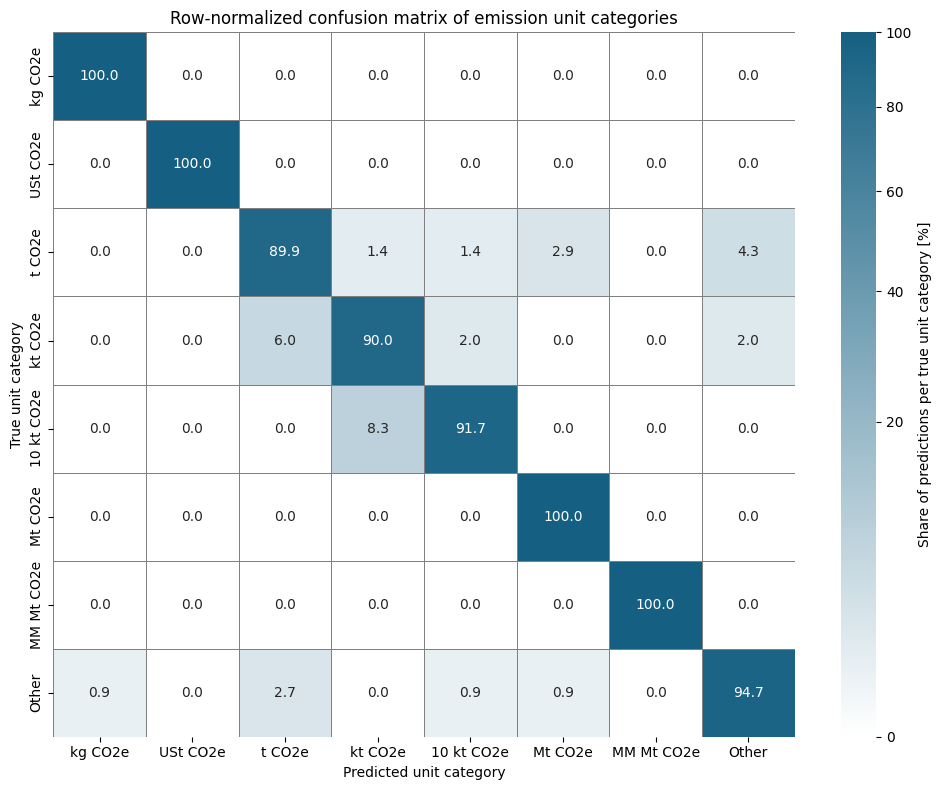


Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               22           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       37      0         0        0   
Other                     1           0        1    107         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   1           0        0      1         0        0   
t CO2e                    1           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             2       0  
MM Mt CO2e             0       0  
Mt CO2e                0       0  
Other          

In [60]:
pipeline_results = full_pipeline(
    ml_model="mlp",  # xgb, lightgbm, logistic_regression, random_forest, svm, mlp, voting_classifier
    # random_state =41
)

print(pipeline_results["split"]["X_train"].iloc[0, 0])

In [4]:
# check which units were predicted wrong
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.max_colwidth",
    None,
    "display.width",
    None,
):
    display(pipeline_results["evaluation"]["abweichungen"])

,true_label,predicted_label,orig_index,unit,pred_max_proba,true_class_proba,is_correct
35,t CO2e,Mt CO2e,590,mt CO₂e,1.000000,3.724364e-14,False
49,kt CO2e,t CO2e,996,th. t CO2 Eq.,1.000000,5.758686e-10,False
56,kt CO2e,Other,85,1.000 t,0.994907,4.495108e-03,False
89,t CO2e,Other,361,metric tons CO2 equivalent (based on 2016 data),0.999973,1.471175e-09,False
101,t CO2e,Other,1220,tonnes CO₂e (due to 100% renewable energy use),1.000000,1.038736e-16,False
120,Other,t CO2e,1071,Tn,0.987097,1.290248e-02,False
196,Other,t CO2e,130,emissions,1.000000,1.720419e-19,False
221,t CO2e,Mt CO2e,601,mtCO2e,1.000000,8.418971e-08,False
246,t CO2e,Other,1340,tons of CO2-eq (2023 data provided for comparison),1.000000,2.178268e-10,False
279,Other,t CO2e,995,Tg COâ‚‚,1.000000,7.436929e-13,False


            count      mean       std       min       25%       50%       75%  \
is_correct                                                                      
False        20.0  0.888198  0.162107  0.425643  0.891622  0.922124  0.995111   
True        350.0  0.974328  0.059487  0.564475  0.982833  0.995910  0.999201   

                 max  
is_correct            
False       0.999951  
True        0.999999  


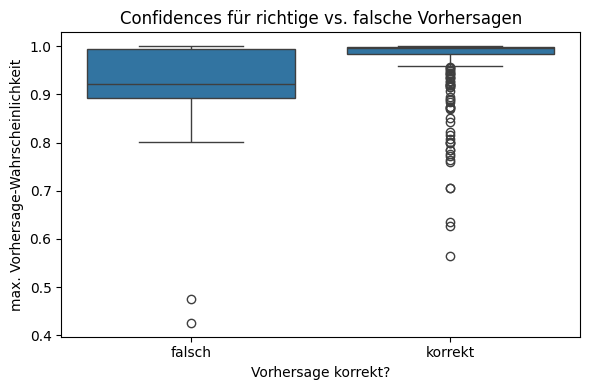

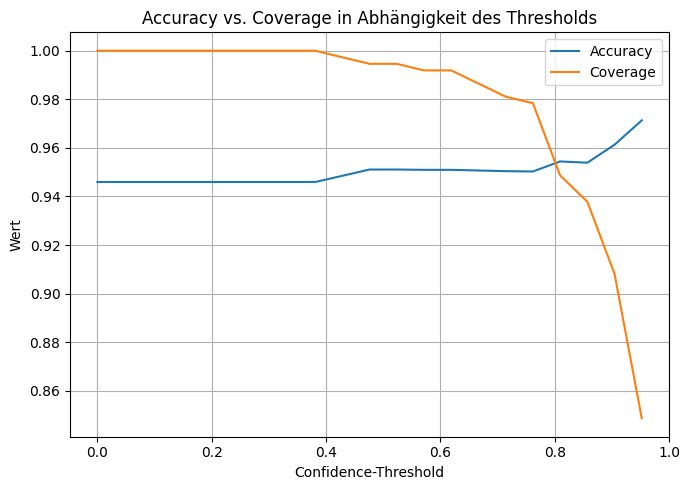

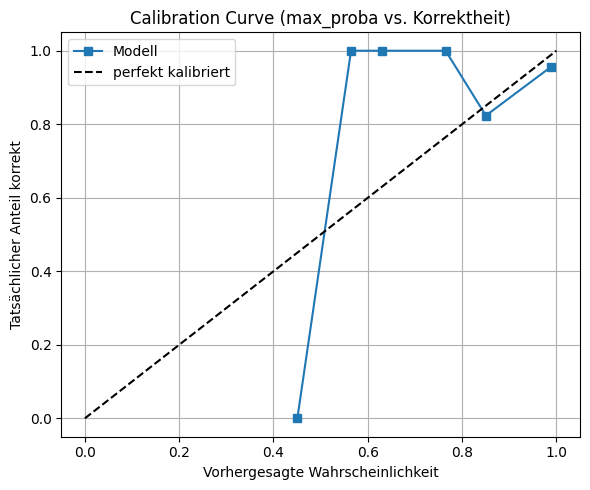

In [ ]:
# analyze confidences: predict probabilitys for predict class and true class
results_df = pipeline_results["evaluation"]["results_df"]
df = results_df.copy()
print(df.groupby("is_correct")["pred_max_proba"].describe())

# plot correlation between correct/false and predict probability
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="is_correct", y="pred_max_proba")
plt.xlabel("Vorhersage korrekt?")
plt.ylabel("max. Vorhersage-Wahrscheinlichkeit")
plt.title("Confidences für richtige vs. falsche Vorhersagen")
plt.xticks([0, 1], ["falsch", "korrekt"])
plt.tight_layout()
plt.show()


# plot Accuracy vs. Coverage in Abhängigkeit des Thresholds
df = results_df.copy()
thresholds = np.linspace(0.0, 1.0, 22)  # z.B. 0.0, 0.05, ..., 1.0

stats = []

for t in thresholds:
    subset = df[df["pred_max_proba"] >= t]
    if len(subset) == 0:
        continue
    acc = accuracy_score(subset["true_label"], subset["predicted_label"])
    coverage = len(subset) / len(df)  # Anteil der Fälle, die überhaupt eine Vorhersage bekommen
    stats.append({"threshold": t, "accuracy": acc, "coverage": coverage})

stats_df = pd.DataFrame(stats)

plt.figure(figsize=(7, 5))
plt.plot(stats_df["threshold"], stats_df["accuracy"], label="Accuracy")
plt.plot(stats_df["threshold"], stats_df["coverage"], label="Coverage")
plt.xlabel("Confidence-Threshold")
plt.ylabel("Wert")
plt.title("Accuracy vs. Coverage in Abhängigkeit des Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot calibration curve
df = results_df.copy()
y_true = df["is_correct"].astype(int)  # 1 = korrekt, 0 = falsch
y_score = df["pred_max_proba"]

prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label="Modell")
plt.plot([0, 1], [0, 1], "k--", label="perfekt kalibriert")
plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
plt.ylabel("Tatsächlicher Anteil korrekt")
plt.title("Calibration Curve (max_proba vs. Korrektheit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
crossvalidate_full_pipeline(
    ml_model="mlp",
    # voting_models=["xgb", "lightgbm", "logistic_regression", "random_forest", "svm", "mlp"],
    # voting_models = ["logistic_regression", "mlp", "xgb"]
    voting_models=["logistic_regression", "mlp", "svm"],
)

Mittlere CV-Scores (+/- Std):
  Accuracy:      94.81% +/- 1.06%
  F1 (weighted): 94.80% +/- 1.05%
  F1 (macro):    96.04% +/- 0.97%
  F1 (micro):     94.81% +/- 1.06%



In [3]:
# try all different combinations of voting classifier with at least 3 models
all_models = ["xgb", "lightgbm", "logistic_regression", "random_forest", "svm", "mlp"]

for r in range(3, len(all_models) + 1):
    for combo in itertools.combinations(all_models, r):
        combo = list(combo)

        print(combo)
        crossvalidate_full_pipeline(ml_model="voting_classifier", voting_models=combo)

['xgb', 'lightgbm', 'logistic_regression']
Mittlere CV-Scores (+/- Std):
  Accuracy:      94.86% +/- 1.50%
  F1 (weighted): 94.86% +/- 1.49%
  F1 (macro):    95.98% +/- 1.07%

['xgb', 'lightgbm', 'random_forest']
Mittlere CV-Scores (+/- Std):
  Accuracy:      94.64% +/- 1.52%
  F1 (weighted): 94.64% +/- 1.51%
  F1 (macro):    95.80% +/- 1.22%

['xgb', 'lightgbm', 'svm']
Mittlere CV-Scores (+/- Std):
  Accuracy:      95.02% +/- 1.30%
  F1 (weighted): 95.02% +/- 1.29%
  F1 (macro):    96.08% +/- 1.00%

['xgb', 'lightgbm', 'mlp']
Mittlere CV-Scores (+/- Std):
  Accuracy:      94.81% +/- 1.42%
  F1 (weighted): 94.81% +/- 1.41%
  F1 (macro):    95.99% +/- 1.02%

['xgb', 'logistic_regression', 'random_forest']
Mittlere CV-Scores (+/- Std):
  Accuracy:      94.97% +/- 1.64%
  F1 (weighted): 94.97% +/- 1.63%
  F1 (macro):    96.16% +/- 1.14%

['xgb', 'logistic_regression', 'svm']
Mittlere CV-Scores (+/- Std):
  Accuracy:      95.35% +/- 1.68%
  F1 (weighted): 95.35% +/- 1.68%
  F1 (macro):    

### Grid or Random Search for best parameters for each model

In [ ]:
# grid search for xgb, already run in xgb file and best result was:
# Beste Genauigkeit: 94.19%
# Bestes Parameter-Grid: {'clf__colsample_bytree': 0.8,
#'clf__gamma': None,
#'clf__learning_rate': 0.2,
#'clf__max_depth': 4,
#'clf__n_estimators': 300,
#'clf__reg_alpha': 0.1,
#'clf__reg_lambda': None,
#'clf__subsample': 1,
#'preprocessor__text__analyzer': 'char_wb',
#'preprocessor__text__max_df': 0.95,
#'preprocessor__text__max_features': 2000,
#'preprocessor__text__min_df': 2,
#'preprocessor__text__ngram_range': (1, 4),
#'preprocessor__text__sublinear_tf': False})

# best restult for optimal tfidf logistc_regression
# Beste(n) Parameter (GridSearch):
# {'clf__colsample_bytree': 0.8,
# 'clf__gamma': None,
# 'clf__learning_rate': 0.2,
# 'clf__max_depth': 4,
# 'clf__n_estimators': 100,
# 'clf__reg_alpha': None,
# 'clf__reg_lambda': 1.5,
# 'clf__subsample': 1}


# run search for best parameters
param_space = {
    # XGBoost
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.2],
    "clf__n_estimators": [100, 300],
    "clf__subsample": [1],
    "clf__colsample_bytree": [0.8],
    "clf__gamma": [None, 0.3],
    "clf__reg_alpha": [None, 0.1],
    "clf__reg_lambda": [None, 1.5],
}

search, stats = search_pipeline(
    param_space=param_space,
    unit_dict_new=pd.read_csv(
        r"../data/unit_normalization_dict.csv"
    ),
    ml_model="xgb",
    mode="grid",  # "grid" oder "random"
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_weighted",
        "logloss": "neg_log_loss",
    },
    refit="f1",  # gibt an, welche Metrik für das beste Modell herangezogen wird
    n_iter=2,  # Nur für RandomizedSearchCV
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Beste(n) Parameter (GridSearch): {'clf__colsample_bytree': 0.8, 'clf__gamma': None, 'clf__learning_rate': 0.2, 'clf__max_depth': 4, 'clf__n_estimators': 100, 'clf__reg_alpha': None, 'clf__reg_lambda': 1.5, 'clf__subsample': 1}
Beste(r/s) accuracy: 0.9365
Beste(r/s) f1: 0.9365
Beste(r/s) logloss: -0.2463
Genauigkeit: 93.24%
Precision (weighted): 93.41%
Recall (weighted):    93.24%
F1-Score (weighted):  93.27%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
Mt CO2e       0.108108     37
Other         0.088496    113
t CO2e        0.086957     69
kt CO2e       0.080000     50
10 kt CO2e    0.041667     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                             

In [ ]:
# grid search for lightgbm
# Beste(n) Parameter (GridSearch):
# {'clf__bagging_freq': 0,
# 'clf__feature_fraction': 1.0,
# 'clf__learning_rate': 0.1,
# 'clf__max_depth': 6,
# 'clf__n_estimators': 100,
# 'clf__num_leaves': 31,
# 'clf__reg_lambda': 0.0}

# best parameters for tfidf with optimal logistic_regression
# Beste(n) Parameter (GridSearch):
# {'clf__bagging_freq': 0,
# 'clf__feature_fraction': 1.0,
# 'clf__learning_rate': 0.1,
# 'clf__max_depth': -1,
# 'clf__n_estimators': 600,
# 'clf__num_leaves': 63,
# 'clf__reg_lambda': 0.0}


param_space = {
    # Komplexität
    "clf__num_leaves": [31, 63],  # 2
    "clf__max_depth": [-1, 6, 8],  # 2
    # Bäume & Lernrate
    "clf__n_estimators": [100, 200, 600],  # 3
    "clf__learning_rate": [0.05, 0.1],  # 2
    # Sampling
    "clf__feature_fraction": [0.8, 1.0],  # 2
    #    "clf__bagging_fraction": [0.8, 1.0],  # 2
    "clf__bagging_freq": [0, 1],  # 2
    # Regularisierung
    "clf__reg_lambda": [0.0, 2.0],  # 3
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="lightgbm",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Beste(n) Parameter (GridSearch): {'clf__bagging_freq': 0, 'clf__feature_fraction': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__n_estimators': 600, 'clf__num_leaves': 63, 'clf__reg_lambda': 0.0}
Beste(r/s) accuracy: 0.9405
Beste(r/s) f1: 0.9406
Beste(r/s) logloss: -0.4630


c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Genauigkeit: 94.32%
Precision (weighted): 94.40%
Recall (weighted):    94.32%
F1-Score (weighted):  94.34%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
t CO2e        0.086957     69
Mt CO2e       0.081081     37
kt CO2e       0.080000     50
Other         0.061947    113
10 kt CO2e    0.041667     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               23           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           1       34      0         0        0   
Other                     0           0        1    106         0        1   
USt CO2e                  0           0        0

In [ ]:
# grid search for logistic regression, 2 solver with only l2 regularization
# Beste(n) Parameter (GridSearch):
# {'clf__C': 100.0,
# 'clf__class_weight': 'balanced',
# 'clf__max_iter': 1000,
# 'clf__penalty': 'l2',
# 'clf__solver': 'newton-cg'}


param_space = {
    # Regularisierungsstärke: klein = starke Regularisierung, groß = schwache
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    # Regularisierungstyp
    "clf__penalty": ["l2"],
    # Klassen-Gewichtung (None = keine, "balanced" = inverse class frequency)
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "newton-cg"],
    "clf__max_iter": [1000, 2000, 3000],
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="logistic_regression",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Beste(n) Parameter (GridSearch): {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'newton-cg'}
Beste(r/s) accuracy: 0.9473
Beste(r/s) f1: 0.9474
Beste(r/s) logloss: -0.2089


c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Genauigkeit: 94.59%
Precision (weighted): 94.73%
Recall (weighted):    94.59%
F1-Score (weighted):  94.62%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
kt CO2e       0.100000     50
t CO2e        0.086957     69
Other         0.061947    113
Mt CO2e       0.054054     37
10 kt CO2e    0.000000     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       35      0         0        0   
Other                     0           0        1    106         0        1   
USt CO2e                  0           0        0

In [ ]:
# grid search for logistic regression, saga solver with both types for regularization
# Beste(n) Parameter (GridSearch):
# {'clf__C': 100.0,
# 'clf__class_weight': 'balanced',
# 'clf__max_iter': 2000,
# 'clf__penalty': 'l2',
# 'clf__solver': 'saga'}


param_space = {
    # Regularisierungsstärke: klein = starke Regularisierung, groß = schwache
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    # Regularisierungstyp
    "clf__penalty": ["l1", "l2"],
    # Klassen-Gewichtung (None = keine, "balanced" = inverse class frequency)
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["saga"],
    "clf__max_iter": [2000],
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="logistic_regression",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Beste(n) Parameter (GridSearch): {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Beste(r/s) accuracy: 0.9466
Beste(r/s) f1: 0.9467
Beste(r/s) logloss: -0.2189


c:\Workspace\BCE\up19040\gist-lmu-bbk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Genauigkeit: 93.78%
Precision (weighted): 94.01%
Recall (weighted):    93.78%
F1-Score (weighted):  93.81%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
kt CO2e       0.100000     50
Other         0.088496    113
t CO2e        0.086957     69
Mt CO2e       0.054054     37
10 kt CO2e    0.000000     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       35      0         0        0   
Other                     1           0        2    103         0        1   
USt CO2e                  0           0        0

In [ ]:
# grid search for random forest
# Beste(n) Parameter (GridSearch):
# {'clf__bootstrap': False,
# 'clf__class_weight': None,
# 'clf__max_depth': 20,
# 'clf__max_features': 'sqrt',
# 'clf__min_samples_leaf': 1,
# 'clf__min_samples_split': 2,
# 'clf__n_estimators': 500}

# optimal tfidf for logistic_regression
# Beste(n) Parameter (GridSearch):
# {'clf__bootstrap': False,
# 'clf__class_weight': None,
# 'clf__max_depth': 20,
# 'clf__max_features': 'sqrt',
# 'clf__min_samples_leaf': 1,
# 'clf__min_samples_split': 10,
# 'clf__n_estimators': 500}


param_space = {
    # Anzahl Bäume
    "clf__n_estimators": [100, 200, 500],  # mehr Bäume = stabiler, langsamer
    # Baumtiefe / Komplexität
    "clf__max_depth": [None, 10, 20],  # None = unbegrenzt
    "clf__min_samples_split": [2, 10],  # min. Samples, um zu splitten
    "clf__min_samples_leaf": [1, 4],  # min. Samples pro Blatt
    # Feature-Sampling pro Split (wichtig!)
    "clf__max_features": ["sqrt", "log2"],  # bei vielen Features: sehr wichtig
    # Bootstrap-Sampling
    "clf__bootstrap": [True, False],  # ob mit Zurücklegen gesampelt wird
    # Klassen-Gewichtung (gegen Imbalance)
    "clf__class_weight": [None, "balanced"],  # optional, bei stark unbalanciert sinnvoll
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="random_forest",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Beste(n) Parameter (GridSearch): {'clf__bootstrap': False, 'clf__class_weight': None, 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Beste(r/s) accuracy: 0.9358
Beste(r/s) f1: 0.9357
Beste(r/s) logloss: -0.2774
Genauigkeit: 92.43%
Precision (weighted): 92.67%
Recall (weighted):    92.43%
F1-Score (weighted):  92.47%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
Mt CO2e       0.135135     37
kt CO2e       0.120000     50
Other         0.088496    113
t CO2e        0.086957     69
10 kt CO2e    0.041667     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                 

In [ ]:
# grid search for support vector machine classifier
# Beste(n) Parameter (GridSearch):
# {'clf__C': 100,
# 'clf__class_weight': 'balanced',
# 'clf__gamma': 'scale',
# 'clf__kernel': 'linear'}

# optimal tfidf for logistic_regression
# Beste(n) Parameter (GridSearch):
# {'clf__C': 10,
# 'clf__class_weight': None,
# 'clf__gamma': 'scale',
# 'clf__kernel': 'linear'}


param_space = {
    # Regularisierungsstärke
    "clf__C": [0.1, 1, 10, 100],
    # Kernel-Typ
    "clf__kernel": ["linear", "rbf"],
    # Gamma nur relevant für rbf (wird bei linear ignoriert)
    "clf__gamma": ["scale", "auto"],
    # Klassen-Gewichtung (bei Imbalance hilfreich)
    "clf__class_weight": [None, "balanced"],
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="svm",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


Beste(n) Parameter (GridSearch): {'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Beste(r/s) accuracy: 0.9480
Beste(r/s) f1: 0.9479
Beste(r/s) logloss: -0.2212
Genauigkeit: 94.05%
Precision (weighted): 94.29%
Recall (weighted):    94.05%
F1-Score (weighted):  94.11%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
Other         0.088496    113
t CO2e        0.086957     69
kt CO2e       0.080000     50
Mt CO2e       0.054054     37
10 kt CO2e    0.000000     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt

In [ ]:
# grid search for multi-layer perceptron classifier (neural network)
# Beste(n) Parameter (GridSearch):
# {'clf__activation': 'tanh',
# 'clf__alpha': 1e-05,
# 'clf__early_stopping': True,
# 'clf__hidden_layer_sizes': (100,),
# 'clf__learning_rate_init': 0.001,
# 'clf__max_iter': 500,
# 'clf__solver': 'lbfgs'}

# optimal tfidf for logistic_regression
# Beste(n) Parameter (GridSearch):
# {'clf__activation': 'tanh',
# 'clf__alpha': 0.001,
# 'clf__early_stopping': True,
# 'clf__hidden_layer_sizes': (200, 100),
# 'clf__learning_rate_init': 0.001,
# 'clf__max_iter': 500,
# 'clf__solver': 'lbfgs'}


param_space = {
    # Netzarchitektur: Anzahl Neuronen pro Layer
    "clf__hidden_layer_sizes": [
        (100,),  # 1 Layer, 100 Neuronen
        (200,),  # 1 Layer, 200 Neuronen
        (100, 100),  # 2 Layer
        (200, 100),  # 2 Layer
    ],
    # Aktivierungsfunktion
    "clf__activation": ["relu", "tanh"],
    # L2-Regularisierung
    "clf__alpha": [1e-5, 1e-4, 1e-3],
    # Lernrate (initial)
    "clf__learning_rate_init": [0.001, 0.01],
    # Solver: Adam ist meist robust, lbfgs gut bei kleineren Datensätzen
    "clf__solver": ["adam", "lbfgs"],  # optional ["adam", "lbfgs"] für mehr Vielfalt
    "clf__max_iter": [500, 1000],
    "clf__early_stopping": [True, False],
}

search, stats = search_pipeline(
    param_space=param_space,
    ml_model="mlp",
    mode="grid",  # "grid" oder "random"
)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Beste(n) Parameter (GridSearch): {'clf__activation': 'tanh', 'clf__alpha': 0.001, 'clf__early_stopping': True, 'clf__hidden_layer_sizes': (200, 100), 'clf__learning_rate_init': 0.001, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
Beste(r/s) accuracy: 0.9466
Beste(r/s) f1: 0.9468
Beste(r/s) logloss: -0.8044
Genauigkeit: 94.59%
Precision (weighted): 94.64%
Recall (weighted):    94.59%
F1-Score (weighted):  94.60%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
t CO2e        0.101449     69
Other         0.070796    113
kt CO2e       0.060000     50
Mt CO2e       0.054054     37
10 kt CO2e    0.000000     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                        

In [ ]:
# grid search for tfidf on logistic regression
# Beste(n) Parameter (GridSearch):
# {'preprocessor__text__analyzer': 'char_wb',
# 'preprocessor__text__max_df': 0.95,
# 'preprocessor__text__max_features': 1000,
# 'preprocessor__text__min_df': 3,
# 'preprocessor__text__ngram_range': (1, 3),
# 'preprocessor__text__sublinear_tf': True}


# run search for best parameters
param_space = {
    "preprocessor__text__ngram_range": [(1, 2), (1, 3), (1, 4), (1, 5)],
    "preprocessor__text__max_features": [1000, 2000, 3000, 5000, 10000],
    "preprocessor__text__min_df": [1, 2, 3],
    "preprocessor__text__max_df": [0.9, 0.95],
    "preprocessor__text__analyzer": ["char_wb"],
    "preprocessor__text__sublinear_tf": [True, False],
}

search, stats = search_pipeline(
    param_space=param_space,
    unit_dict_new=pd.read_csv(
        r"../data/unit_normalization_dict.csv"
    ),
    ml_model="logistic_regression",
    mode="grid",  # "grid" oder "random"
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_weighted",
        "logloss": "neg_log_loss",
    },
    refit="f1",  # gibt an, welche Metrik für das beste Modell herangezogen wird
    n_iter=2,  # Nur für RandomizedSearchCV
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Beste(n) Parameter (GridSearch): {'preprocessor__text__analyzer': 'char_wb', 'preprocessor__text__max_df': 0.95, 'preprocessor__text__max_features': 1000, 'preprocessor__text__min_df': 3, 'preprocessor__text__ngram_range': (1, 3), 'preprocessor__text__sublinear_tf': True}
Beste(r/s) accuracy: 0.9446
Beste(r/s) f1: 0.9446
Beste(r/s) logloss: -0.2252
Genauigkeit: 93.51%
Precision (weighted): 93.67%
Recall (weighted):    93.51%
F1-Score (weighted):  93.54%
=== FEHLERSTATISTIK ===
Fehlerrate pro Klasse:
             mean_error  count
true_label                   
kt CO2e       0.120000     50
t CO2e        0.086957     69
Mt CO2e       0.081081     37
Other         0.070796    113
10 kt CO2e    0.041667     24
MM Mt CO2e    0.000000     29
kg CO2e       0.000000     25
USt CO2e      0.000000     23

Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label             

### Robustness test on rare real units

=== HAUPTMETRIKEN ===
Accuracy:          93.49%
F1-Score weighted: 93.52%
F1-Score macro:    91.99%

F1-Score micro:    93.49%

=== WEITERE METRIKEN (weighted) ===
Precision:         93.66%
Recall:            93.49%
F1-Score weighted: 93.52%

=== FEHLERSTATISTIK + METRIKEN PRO KLASSE ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
t CO2e          0.1176     68     0.9231  0.8824  0.9023       68
Mt CO2e         0.0833     36     0.9429  0.9167  0.9296       36
kg CO2e         0.0526     19     1.0000  0.9474  0.9730       19
Other           0.0442    113     0.9391  0.9558  0.9474      113
kt CO2e         0.0408     49     0.9216  0.9592  0.9400       49
MM Mt CO2e      0.0000      1     1.0000  1.0000  1.0000        1
10 kt CO2e      0.0000      1     0.5000  1.0000  0.6667        1
USt CO2e        0.0000      5     1.0000  1.0000  1.0000        5


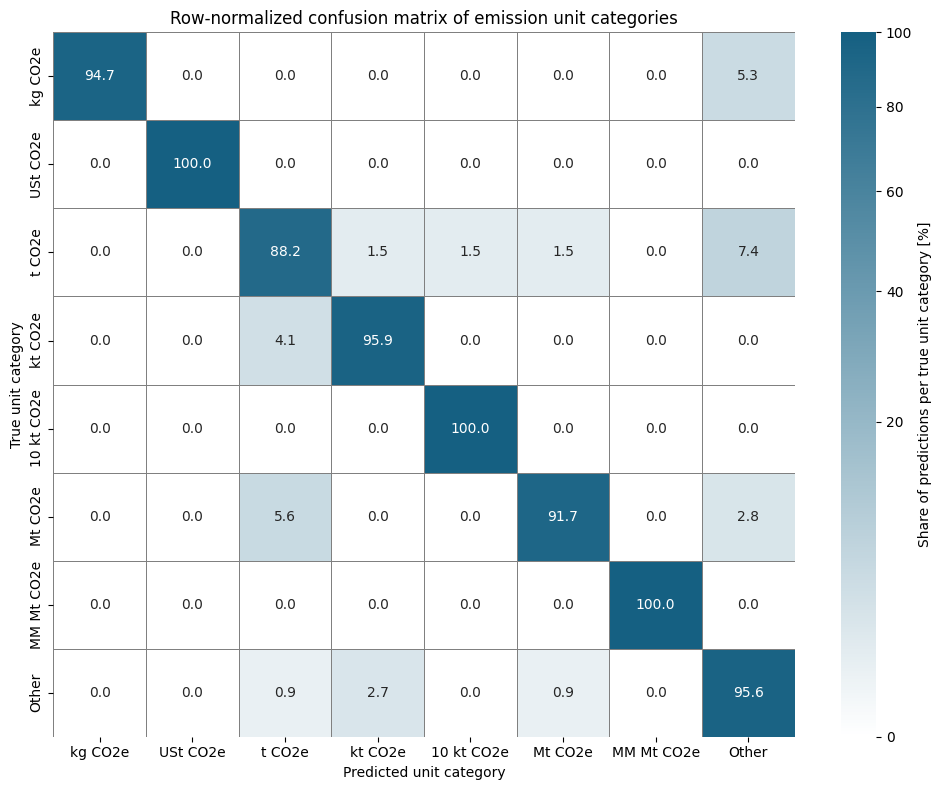


Am häufigsten verwechselt:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e                1           0        0      0         0        0   
MM Mt CO2e                0           1        0      0         0        0   
Mt CO2e                   0           0       33      1         0        0   
Other                     0           0        1    108         0        0   
USt CO2e                  0           0        0      0         5        0   
kg CO2e                   0           0        0      1         0       18   
kt CO2e                   0           0        0      0         0        0   
t CO2e                    1           0        1      5         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       2  
Other          

In [76]:
# robustness with rare units
pipeline_results = full_pipeline(
    split_by_count=True,
    ml_model="mlp",
    max_count=5,  # only necessary if split_by_count is True
    include_artificial=False,  # only necessary if split_by_count is True
)

In [ ]:
# check which units were predicted wrong
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.max_colwidth",
    None,
    "display.width",
    None,
):
    display(pipeline_results["evaluation"]["abweichungen"])

,true_label,predicted_label,orig_index,unit,pred_max_proba,true_class_proba,is_correct
33,t CO2e,Other,670,t CO2 (remaining emissions),NaN,NaN,False
44,kg CO2e,Other,175,kg CO2eq per year,NaN,NaN,False
133,Mt CO2e,Other,454,million t CO2e (Category 3),NaN,NaN,False
136,Mt CO2e,Other,436,million metric tons of CO2 eq. (Pro forma),NaN,NaN,False
146,kt CO2e,t CO2e,996,th. t CO2 Eq.,NaN,NaN,False
154,Other,kt CO2e,304,kts,NaN,NaN,False
157,t CO2e,Other,922,tCO2e (sum of all Scope 3 categories provided),NaN,NaN,False
188,t CO2e,Other,1220,tonnes CO₂e (due to 100% renewable energy use),NaN,NaN,False
190,Other,kt CO2e,232,kt CO2e (sum of all categories listed for 2022),NaN,NaN,False
201,kt CO2e,Other,53,'000 tCO₂e,NaN,NaN,False


### analyze confidences of predictions

            count      mean       std       min       25%       50%       75%  \
is_correct                                                                      
False        20.0  0.763058  0.181494  0.452027  0.568565  0.795804  0.895441   
True        272.0  0.954743  0.097280  0.467531  0.964015  0.994437  0.998981   

                 max  
is_correct            
False       0.999674  
True        1.000000  


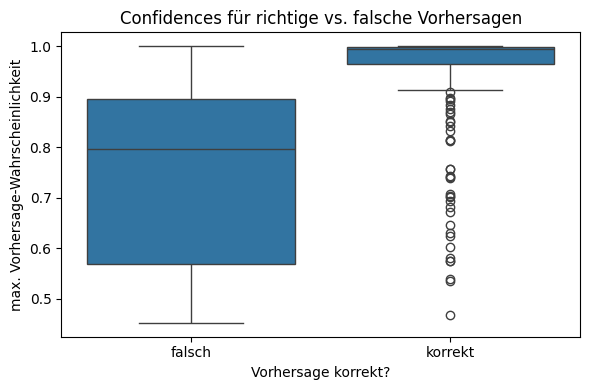

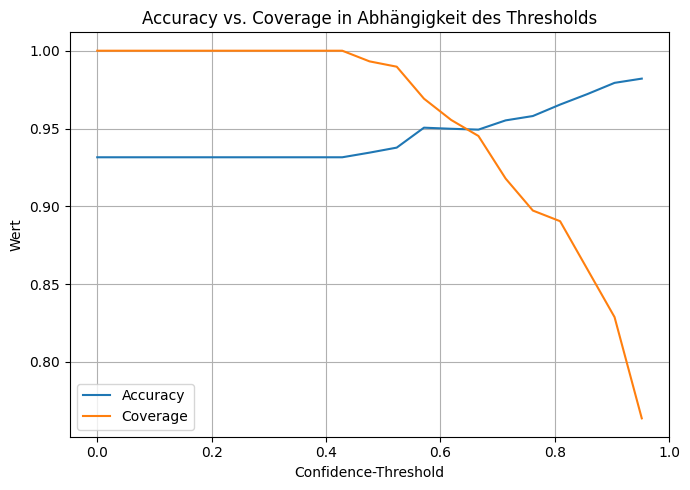

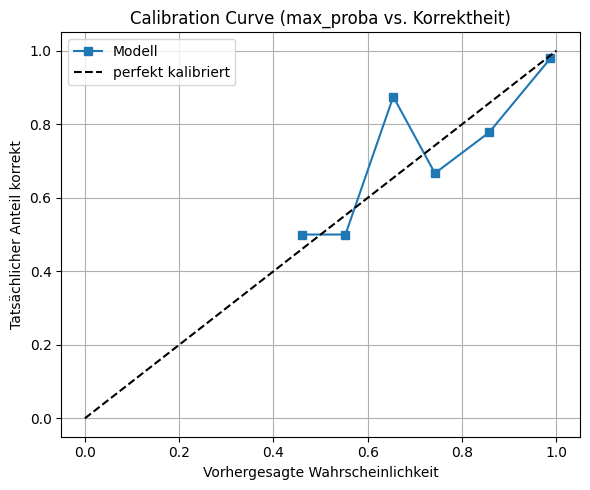

In [ ]:
# analyze confidences: predict probabilitys for predict class and true class
results_df = pipeline_results["evaluation"]["results_df"]
df = results_df.copy()
print(df.groupby("is_correct")["pred_max_proba"].describe())

# plot correlation between correct/false and predict probability
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="is_correct", y="pred_max_proba")
plt.xlabel("Vorhersage korrekt?")
plt.ylabel("max. Vorhersage-Wahrscheinlichkeit")
plt.title("Confidences für richtige vs. falsche Vorhersagen")
plt.xticks([0, 1], ["falsch", "korrekt"])
plt.tight_layout()
plt.show()


# plot Accuracy vs. Coverage in Abhängigkeit des Thresholds
df = results_df.copy()
thresholds = np.linspace(0.0, 1.0, 22)  # z.B. 0.0, 0.05, ..., 1.0

stats = []

for t in thresholds:
    subset = df[df["pred_max_proba"] >= t]
    if len(subset) == 0:
        continue
    acc = accuracy_score(subset["true_label"], subset["predicted_label"])
    coverage = len(subset) / len(df)  # Anteil der Fälle, die überhaupt eine Vorhersage bekommen
    stats.append({"threshold": t, "accuracy": acc, "coverage": coverage})

stats_df = pd.DataFrame(stats)

plt.figure(figsize=(7, 5))
plt.plot(stats_df["threshold"], stats_df["accuracy"], label="Accuracy")
plt.plot(stats_df["threshold"], stats_df["coverage"], label="Coverage")
plt.xlabel("Confidence-Threshold")
plt.ylabel("Wert")
plt.title("Accuracy vs. Coverage in Abhängigkeit des Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot calibration curve
df = results_df.copy()
y_true = df["is_correct"].astype(int)  # 1 = korrekt, 0 = falsch
y_score = df["pred_max_proba"]

prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label="Modell")
plt.plot([0, 1], [0, 1], "k--", label="perfekt kalibriert")
plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
plt.ylabel("Tatsächlicher Anteil korrekt")
plt.title("Calibration Curve (max_proba vs. Korrektheit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Results for trivial baseline of majority-class classifier

In [ ]:
# get results for trivial baseline of majority-class classifier
unit_dict_new = pd.read_csv(
    r"../data/unit_normalization_dict.csv"
)
ml_model = "voting_classifier"
voting_models = None

X, y_encoded, _ = create_features_and_labels(unit_dict_new, extract_quantity_keyword, clean_unit)

pipeline = build_and_train_pipeline(X, y_encoded, ml_model, voting_models, mode="build_only")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Listen für die Scores der Majority-Baseline
acc_scores = []
f1_weighted_scores = []
f1_macro_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded)):
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    print(f"Fold {fold_idx}")
    print("  Train-Verteilung:", np.bincount(y_train))
    print("  Test-Verteilung: ", np.bincount(y_test))
    print("  Summe y_test:    ", sum(y_test))

    # Majority-Klasse im Training-Fold bestimmen
    values, counts = np.unique(y_train, return_counts=True)
    majority_class = values[np.argmax(counts)]

    # Vorhersage: immer Majority-Klasse
    y_pred = np.full_like(y_test, fill_value=majority_class)

    # Metriken berechnen
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    acc_scores.append(acc)
    f1_weighted_scores.append(f1_w)
    f1_macro_scores.append(f1_m)

    print(
        f"  Majority-Baseline: " f"Accuracy={acc:.4f}, F1_weighted={f1_w:.4f}, F1_macro={f1_m:.4f}"
    )

# In Arrays umwandeln
acc_scores = np.array(acc_scores)
f1_weighted_scores = np.array(f1_weighted_scores)
f1_macro_scores = np.array(f1_macro_scores)

print("\nGesamt (Majority-Baseline über alle Folds):")
print(f"Accuracy:    mean={acc_scores.mean():.4f}, std={acc_scores.std():.4f}")
print(f"F1_weighted: mean={f1_weighted_scores.mean():.4f}, " f"std={f1_weighted_scores.std():.4f}")
print(f"F1_macro:    mean={f1_macro_scores.mean():.4f}, " f"std={f1_macro_scores.std():.4f}")


# für 80/20 held-out test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Majority-Klasse im TRAIN-Set
values, counts = np.unique(y_train, return_counts=True)
majority_class = values[np.argmax(counts)]

# Baseline-Vorhersage: immer Majority-Klasse
y_pred_majority = np.full_like(y_test, fill_value=majority_class)

# Baseline-Metriken
acc_maj = accuracy_score(y_test, y_pred_majority)
f1w_maj = f1_score(y_test, y_pred_majority, average="weighted", zero_division=0)
f1m_maj = f1_score(y_test, y_pred_majority, average="macro", zero_division=0)

print("\nMajority-Baseline auf 80/20-Holdout:")
print(f"  Accuracy:     {acc_maj:.4f}")
print(f"  F1_weighted:  {f1w_maj:.4f}")
print(f"  F1_macro:     {f1m_maj:.4f}")

Fold 0
  Train-Verteilung: [108 129 166 510 104 114 224 309]
  Test-Verteilung:  [12 15 18 57 12 12 25 34]
  Summe y_test:     718
  Majority-Baseline: Accuracy=0.3081, F1_weighted=0.1451, F1_macro=0.0589
Fold 1
  Train-Verteilung: [108 129 166 510 104 114 224 309]
  Test-Verteilung:  [12 15 18 57 12 12 25 34]
  Summe y_test:     718
  Majority-Baseline: Accuracy=0.3081, F1_weighted=0.1451, F1_macro=0.0589
Fold 2
  Train-Verteilung: [108 129 166 510 104 114 224 309]
  Test-Verteilung:  [12 15 18 57 12 12 25 34]
  Summe y_test:     718
  Majority-Baseline: Accuracy=0.3081, F1_weighted=0.1451, F1_macro=0.0589
Fold 3
  Train-Verteilung: [108 129 166 510 105 113 224 309]
  Test-Verteilung:  [12 15 18 57 11 13 25 34]
  Summe y_test:     719
  Majority-Baseline: Accuracy=0.3081, F1_weighted=0.1451, F1_macro=0.0589
Fold 4
  Train-Verteilung: [108 130 166 510 105 113 224 308]
  Test-Verteilung:  [12 14 18 57 11 13 25 35]
  Summe y_test:     725
  Majority-Baseline: Accuracy=0.3081, F1_weighted

In [ ]:
# code for testing feature importance

from sklearn.inspection import permutation_importance

pipeline = pipeline_results["pipeline"]
X_test = pipeline_results["split"]["X_test"]
y_test = pipeline_results["split"]["y_test"]


X_test_feats = X_test.drop(columns="orig_index")
result = permutation_importance(
    pipeline,
    X_test_feats,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)
importances = result.importances_mean
imp_df = pd.DataFrame({"feature": X_test_feats.columns, "importance": importances})
print(imp_df.sort_values("importance", ascending=False))
print(f"Länge-Feature Importance: {importances[-1]:.4f}")